In [1]:
from pathlib import Path
from datetime import datetime
import quant
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore')

In [2]:
CONFIG_PATH = Path(str(__vsc_ipynb_file__)).parent.parent.parent / "lseg-data.config.json"
VIX_PATH = Path(str(__vsc_ipynb_file__)).parent.parent.parent / "data" / "vix.csv"
session = quant.SessionProvider(CONFIG_PATH)

In [3]:
vix = pd.read_csv(VIX_PATH, sep='\t', parse_dates=True, index_col=0).rename(columns={"Close": "VIX_Close"})

In [4]:
with session as client:
    bonds = client.bonds.list_securities("Altria Group Inc")
    stocks = client.equities.list_securities("Altria Group Inc")
    
    common_stock = next(filter(lambda stock: stock.ric == "MO", stocks))

In [5]:
common_stock.name, len(bonds)

('Altria Group Inc, Ordinary Share, NYSE Consolidated', 20)

In [6]:
study = quant.study.fi_ltm.FILtmStudy(datetime(1997, 1, 18), datetime(2026, 1, 17), quant.Interval.DAILY, vix)

In [7]:
ready_to_run = study.prepare_args(common_stock, bonds, 0.045)

In [8]:
df_results = ready_to_run.run(session)

Pull IV history
Pull stock history


Pull bond history: 7it [02:30, 21.55s/it]
Build engineered features: 100%|██████████| 17/17 [00:12<00:00,  1.38it/s]


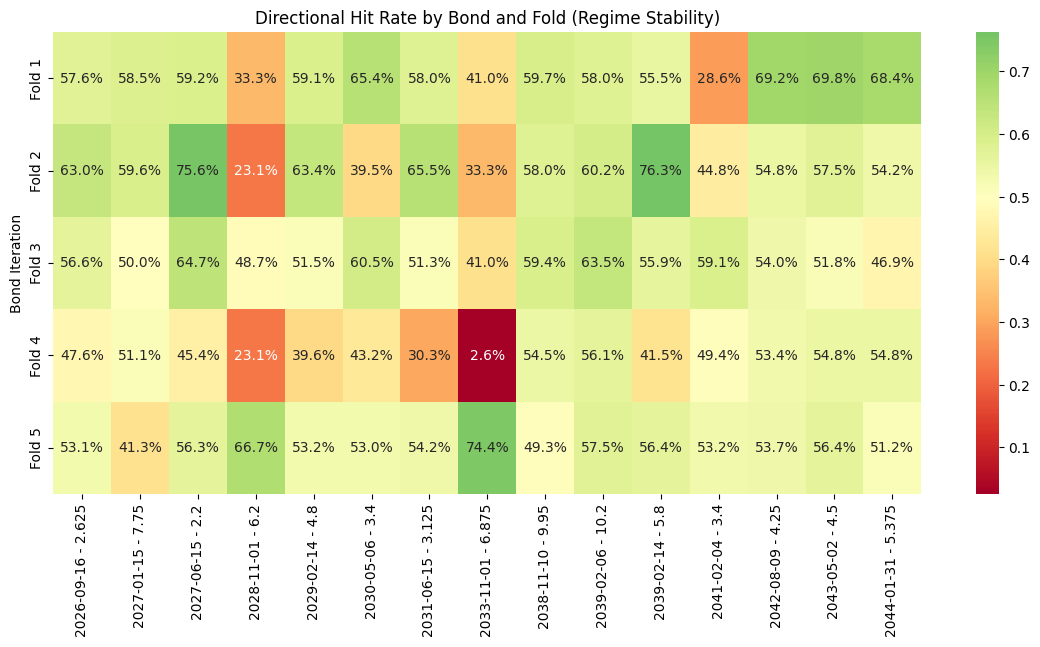

In [10]:
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.heatmap(df_results, annot=True, fmt=".1%", cmap="RdYlGn", center=0.5)
plt.title("Directional Hit Rate by Bond and Fold (Regime Stability)")
plt.ylabel("Bond Iteration")
plt.show()